# EDA — NASA C-MAPSS (FD001 & FD004)

Goal of this notebook: understand the degradation signal well enough to build
a sensible baseline, and — most importantly for this project — **document the
class imbalance in the failure signal**, since that's the problem Phase 2's
digital-twin simulator exists to address.

We look at FD001 (1 operating condition, 1 fault mode) and FD004 (6 operating
conditions, 2 fault modes) side by side throughout.

In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from guardian.data.columns import CONSTANT_SENSORS_FD001, OP_SETTING_COLS, SENSOR_COLS
from guardian.data.labeling import add_train_rul, RUL_CLIP
from guardian.data.loader import load_train, load_test, load_test_rul
from guardian.data.regimes import RegimeNormalizer

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 30)

fd001 = add_train_rul(load_train("FD001"), clip=None)
fd004 = add_train_rul(load_train("FD004"), clip=None)
fd001.shape, fd004.shape

((20631, 27), (61249, 27))

## 1. What a trajectory looks like

Each engine runs normally, then degrades until failure. A few raw sensors
already show a visible trend across an engine's life in FD001 — this is the
signal the model is trying to learn.

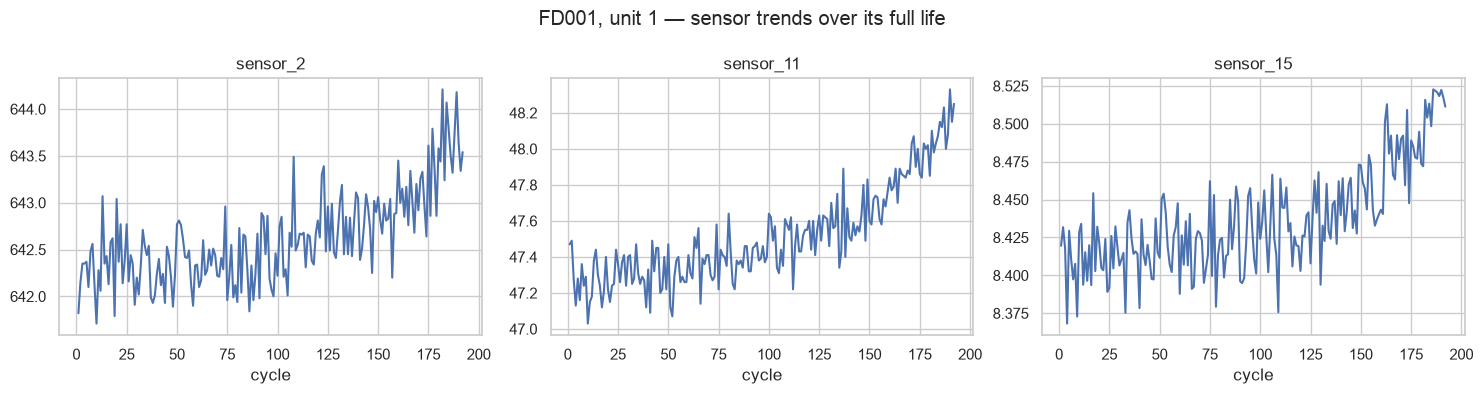

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
example_unit = fd001[fd001["unit_number"] == 1]
for ax, sensor in zip(axes, ["sensor_2", "sensor_11", "sensor_15"]):
    ax.plot(example_unit["time_cycles"], example_unit[sensor])
    ax.set_title(sensor)
    ax.set_xlabel("cycle")
fig.suptitle("FD001, unit 1 — sensor trends over its full life")
fig.tight_layout()

## 2. Not every sensor carries signal

Several sensors are constant (to sensor noise only) in FD001 because it runs
a single operating condition — no information to extract, so we drop them
before modeling (`CONSTANT_SENSORS_FD001` in `guardian.data.columns`).

In [3]:
fd001[SENSOR_COLS].std().sort_values().to_frame("std_dev")

,std_dev
sensor_1,0.000000e+00
sensor_19,0.000000e+00
sensor_18,0.000000e+00
sensor_10,0.000000e+00
sensor_16,3.469531e-18
sensor_5,5.329200e-15
sensor_6,1.388985e-03
sensor_15,3.750504e-02
sensor_8,7.098548e-02
sensor_13,7.191892e-02


## 3. FD004's operating regimes confound the raw sensor values

FD004 cycles through six discrete operating conditions. Below, the same
sensor's raw value clusters by *regime*, not by health — the degradation
trend within a regime is much smaller than the jump between regimes. Any
model reading raw sensor values here would mostly be learning "which regime
is this," not "how degraded is this engine."

This is why `guardian.data.regimes.RegimeNormalizer` clusters on the
operational settings and z-scores each sensor within its own regime before
either baseline model sees it.

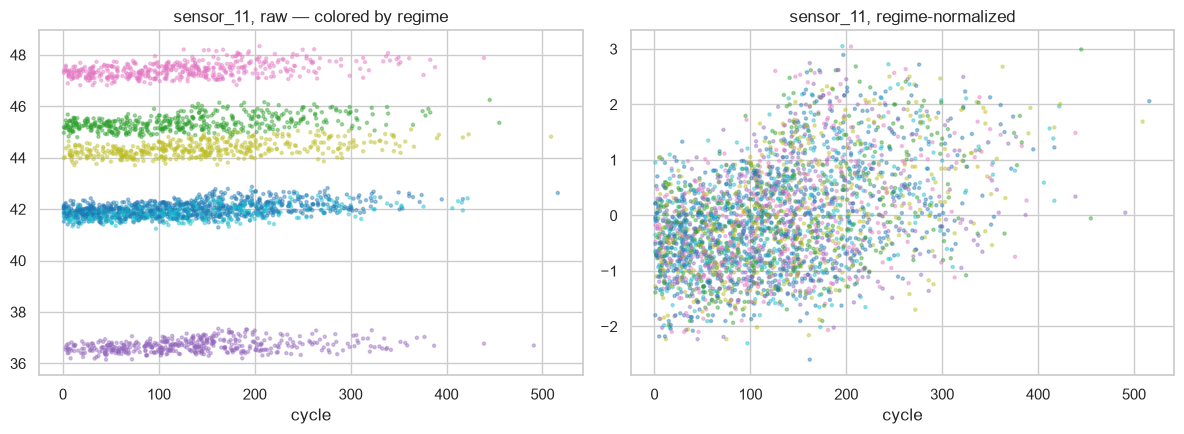

In [4]:
normalizer = RegimeNormalizer()
fd004_norm = normalizer.fit_transform(fd004)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sample = fd004.sample(3000, random_state=0)
sample_norm = fd004_norm.loc[sample.index]

axes[0].scatter(sample["time_cycles"], sample["sensor_11"], s=5, alpha=0.4,
                c=sample_norm["regime"], cmap="tab10")
axes[0].set_title("sensor_11, raw — colored by regime")
axes[0].set_xlabel("cycle")

axes[1].scatter(sample_norm["time_cycles"], sample_norm["sensor_11"], s=5, alpha=0.4,
                c=sample_norm["regime"], cmap="tab10")
axes[1].set_title("sensor_11, regime-normalized")
axes[1].set_xlabel("cycle")
fig.tight_layout()

## 4. The core problem: rare-event class imbalance

Frame RUL regression as the operational question that actually matters:
*is this engine about to fail?* Call a cycle with true RUL ≤ 20 an
"imminent failure" cycle. Below is what fraction of all observed cycles fall
into that class, for both subsets.

In [5]:
THRESH = 20

def imbalance_summary(df, name):
    total = len(df)
    positive = (df["RUL"] <= THRESH).sum()
    return {
        "subset": name,
        "total_cycles": total,
        "imminent_failure_cycles": positive,
        "positive_rate": positive / total,
    }

summary = pd.DataFrame([
    imbalance_summary(fd001, "FD001"),
    imbalance_summary(fd004, "FD004"),
])
summary

,subset,total_cycles,imminent_failure_cycles,positive_rate
0,FD001,20631,2100,0.101789
1,FD004,61249,5229,0.085373


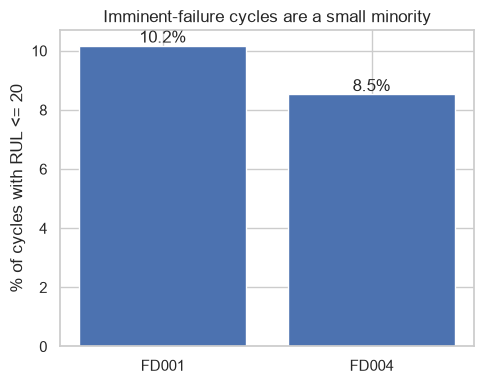

In [6]:
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(summary["subset"], summary["positive_rate"] * 100)
ax.set_ylabel("% of cycles with RUL <= 20")
ax.set_title("Imminent-failure cycles are a small minority")
for i, v in enumerate(summary["positive_rate"] * 100):
    ax.text(i, v + 0.1, f"{v:.1f}%", ha="center")
fig.tight_layout()

Both subsets: **fewer than 1 in 10 cycles** represent an engine actually
close to failure. A model (or a human) that never flags a failure would
already be "right" ~90%+ of the time by raw accuracy — which is exactly why
Section 5 below looks at *recall on the imminent-failure class specifically*,
not overall error, and why Phase 2 augments this rare class rather than
just collecting more normal-operation data.

At the *unit* level it's structural, not just a labeling artifact: every
engine contributes many "healthy" cycles and only a handful of "about to
fail" ones, by construction of how RUL is defined.

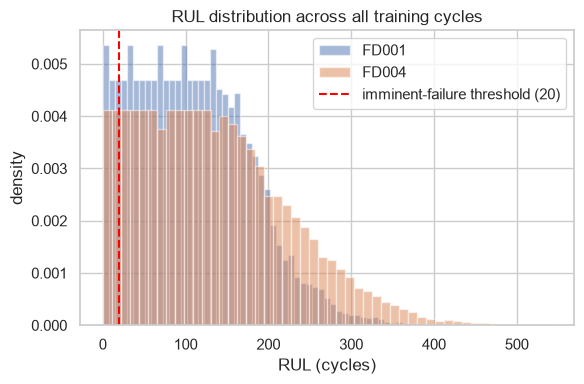

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
for name, df, color in [("FD001", fd001, "C0"), ("FD004", fd004, "C1")]:
    ax.hist(df["RUL"], bins=50, alpha=0.5, label=name, color=color, density=True)
ax.axvline(THRESH, color="red", linestyle="--", label=f"imminent-failure threshold ({THRESH})")
ax.set_xlabel("RUL (cycles)")
ax.set_ylabel("density")
ax.set_title("RUL distribution across all training cycles")
ax.legend()
fig.tight_layout()

## 5. Baseline model performance on the rare class

Phase 1's baseline models (GBM and LSTM, see `scripts/train.py`) are
evaluated with this framing in mind — RMSE/MAE plus precision/recall on the
imminent-failure class (`guardian.eval.metrics.imminent_failure_prf`), and
the PHM08 asymmetric score that penalizes late (overestimated-RUL)
predictions harder than early ones. Results from the trained runs
(see `mlflow.db` / `outputs/plots/`):

| Subset | Model | Test RMSE | Imminent-failure recall |
|--------|-------|-----------|---------------------------|
| FD001  | GBM   | ~17.8     | ~0.69                     |
| FD001  | LSTM  | ~22.6     | ~0.81                     |
| FD004  | GBM   | ~30.1     | ~0.65                     |
| FD004  | LSTM  | ~28.1     | ~0.95                     |

Even the better of the two baselines misses a meaningful share of the
engines that are actually about to fail — this is the gap Phase 2's
synthetic failure trajectories are meant to close, by giving the models many
more *examples of the rare class* to learn from, rather than by making the
model itself more complex.